In [4]:
import skfuzzy as fuzz
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [6]:
def print_img(img:np.array):
    plt.imshow(img, cmap='gray')
    plt.axis('off') 
    plt.show()



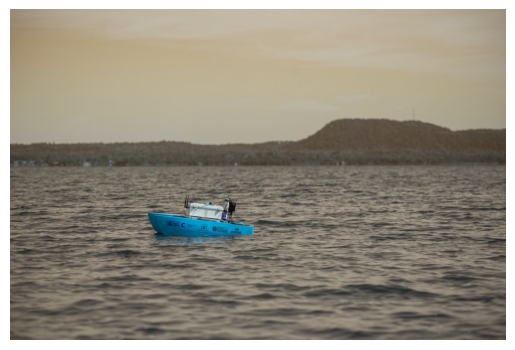

In [59]:
img = cv2.imread("/home/tille/Desktop/Tesis/code/img/barco.jpg")
print_img(img)

In [58]:
img = cv2.imread("/home/tille/Desktop/Tesis/code/img/barco.jpg",cv2.IMREAD_GRAYSCALE)
n,m = img.shape
img = img[int(n/2.13):n,0:m]
n,m = img.shape
g_max = img.max()
g_min = img.min()
mapped = (img-g_min)/(g_max-g_min)
print_img(img)




ValueError: too many values to unpack (expected 2)

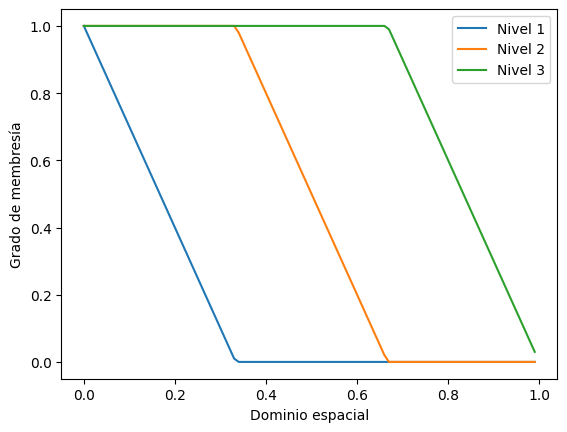

In [33]:
x = np.arange(0, 1, 0.01)

Cp0 = 0
Cp1 = 1/3
Cp2 = 2/3
Cp3 = 1
# Crear las funciones de membresía
mf1 = fuzz.trapmf(x,[0,0,Cp0,Cp1])
mf2 = fuzz.trapmf(x, [0,0,Cp1,Cp2])
mf3 = fuzz.trapmf(x, [0,0,Cp2,Cp3])

# Visualizar las funciones de membresía
plt.plot(x, mf1, label='Nivel 1')
plt.plot(x, mf2, label='Nivel 2')
plt.plot(x, mf3, label='Nivel 3')
plt.xlabel('Dominio espacial')
plt.ylabel('Grado de membresía')
plt.legend()
plt.show()

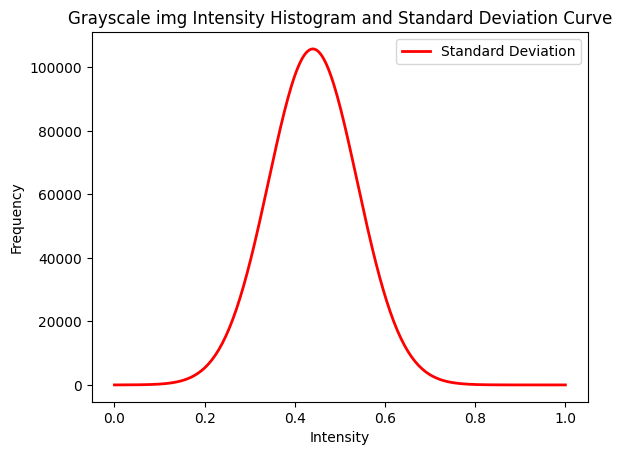

In [56]:
std_dev = np.std(mapped)

# Crear un histograma de las intensidades de la mappedn
hist, bins = np.histogram(mapped.flatten(), bins=256, range=[0, 1])

# Crear un rango de valores para la curva de desviación estándar
x = np.linspace(0, 1, 256)

# Calcular la curva de desviación estándar
y = np.exp(-0.5 * ((x - np.mean(mapped)) / std_dev) ** 2) / (std_dev * np.sqrt(2 * np.pi))

# Graficar el histograma y la curva de desviación estándar
# plt.bar(bins[:-1], hist, width=1, color='gray', alpha=0.5, label='Histogram')
plt.plot(x, y * np.max(hist), 'r', linewidth=2, label='Standard Deviation')
plt.title('Grayscale img Intensity Histogram and Standard Deviation Curve')
plt.xlabel('Intensity')
plt.ylabel('Frequency')
plt.legend()
plt.show()